## Тепловая карта (Heatmap)

In [19]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

## 1 Установливаем соединение с базой данных.

In [20]:
conn = sqlite3.connect('/Users/cleganeb/Desktop/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/data/checking-logs.sqlite')

## 2 Достанем и подготовим данные из таблицы checker (только пользователи).

In [21]:
query = """
SELECT  uid, 
        timestamp as date
    FROM checker
    WHERE uid LIKE 'user_%'
"""
checker = pd.io.sql.read_sql(query, conn)

display(checker)

,uid,date
0,user_4,2020-04-17 05:19:02.744528
1,user_4,2020-04-17 05:22:35.249331
2,user_4,2020-04-17 05:22:45.549397
3,user_4,2020-04-17 05:34:14.691200
4,user_4,2020-04-17 05:34:24.422370
...,...,...
3202,user_1,2020-05-21 20:19:06.872761
3203,user_1,2020-05-21 20:22:41.785725
3204,user_1,2020-05-21 20:22:41.877806
3205,user_1,2020-05-21 20:37:00.129678


In [22]:
checker['date'] = pd.to_datetime(checker['date'])
checker['hour'] = checker['date'].dt.hour
checker['num_day'] = checker['date'].dt.dayofweek
labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
checker["week_day"] = checker["num_day"].map(lambda x: labels[x])
display(checker)

,uid,date,hour,num_day,week_day
0,user_4,2020-04-17 05:19:02.744528,5,4,Fri
1,user_4,2020-04-17 05:22:35.249331,5,4,Fri
2,user_4,2020-04-17 05:22:45.549397,5,4,Fri
3,user_4,2020-04-17 05:34:14.691200,5,4,Fri
4,user_4,2020-04-17 05:34:24.422370,5,4,Fri
...,...,...,...,...,...
3202,user_1,2020-05-21 20:19:06.872761,20,3,Thu
3203,user_1,2020-05-21 20:22:41.785725,20,3,Thu
3204,user_1,2020-05-21 20:22:41.877806,20,3,Thu
3205,user_1,2020-05-21 20:37:00.129678,20,3,Thu


## 3 На основе полученых данных подготовим 2 таблицы по которым будет строиться тепловая карта.

In [23]:
day = checker.groupby(['week_day', 'uid']).size().unstack(fill_value=0).reindex(index=labels)
sort_day = day.sum(axis=0).sort_values(ascending=False).index
day = day[sort_day]
display(day)

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_11,user_7,user_22,user_23,user_0
week_day,,,,,,,,,,,,,,,,,,,,,
Mon,35,50,24,14,7,0,23,5,0,46,...,8,10,0,0,1,0,0,2,0,3
Tue,86,87,131,44,9,1,0,0,16,11,...,4,5,0,0,0,0,5,3,0,0
Wed,33,0,32,15,0,34,8,0,37,0,...,1,0,0,0,4,0,3,0,0,0
Thu,108,17,4,40,78,51,96,7,77,7,...,17,14,15,5,2,0,0,2,6,0
Fri,61,0,0,10,10,2,7,35,1,59,...,0,0,0,0,0,0,0,0,0,0
Sat,0,79,31,66,21,16,3,90,4,3,...,32,0,0,4,2,0,0,0,0,0
Sun,45,26,13,44,51,69,28,7,2,8,...,0,31,27,20,9,8,0,1,0,0


In [24]:
hour = checker.groupby(['hour', 'uid']).size().unstack(fill_value=0).reindex(index=list(range(24)), fill_value=0)
hour = hour[sort_day]
display(hour)

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_11,user_7,user_22,user_23,user_0
hour,,,,,,,,,,,,,,,,,,,,,
0,0,4,0,0,0,4,0,2,0,0,...,0,0,0,0,2,0,0,0,0,0
1,0,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,13,0,2,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,3,6,0,0,10,2,0,3,0,...,1,0,0,0,0,0,0,0,0,0
8,0,6,0,0,0,5,2,0,9,6,...,2,0,0,0,0,0,1,0,1,0


## 4 Построим тепловую карту. 

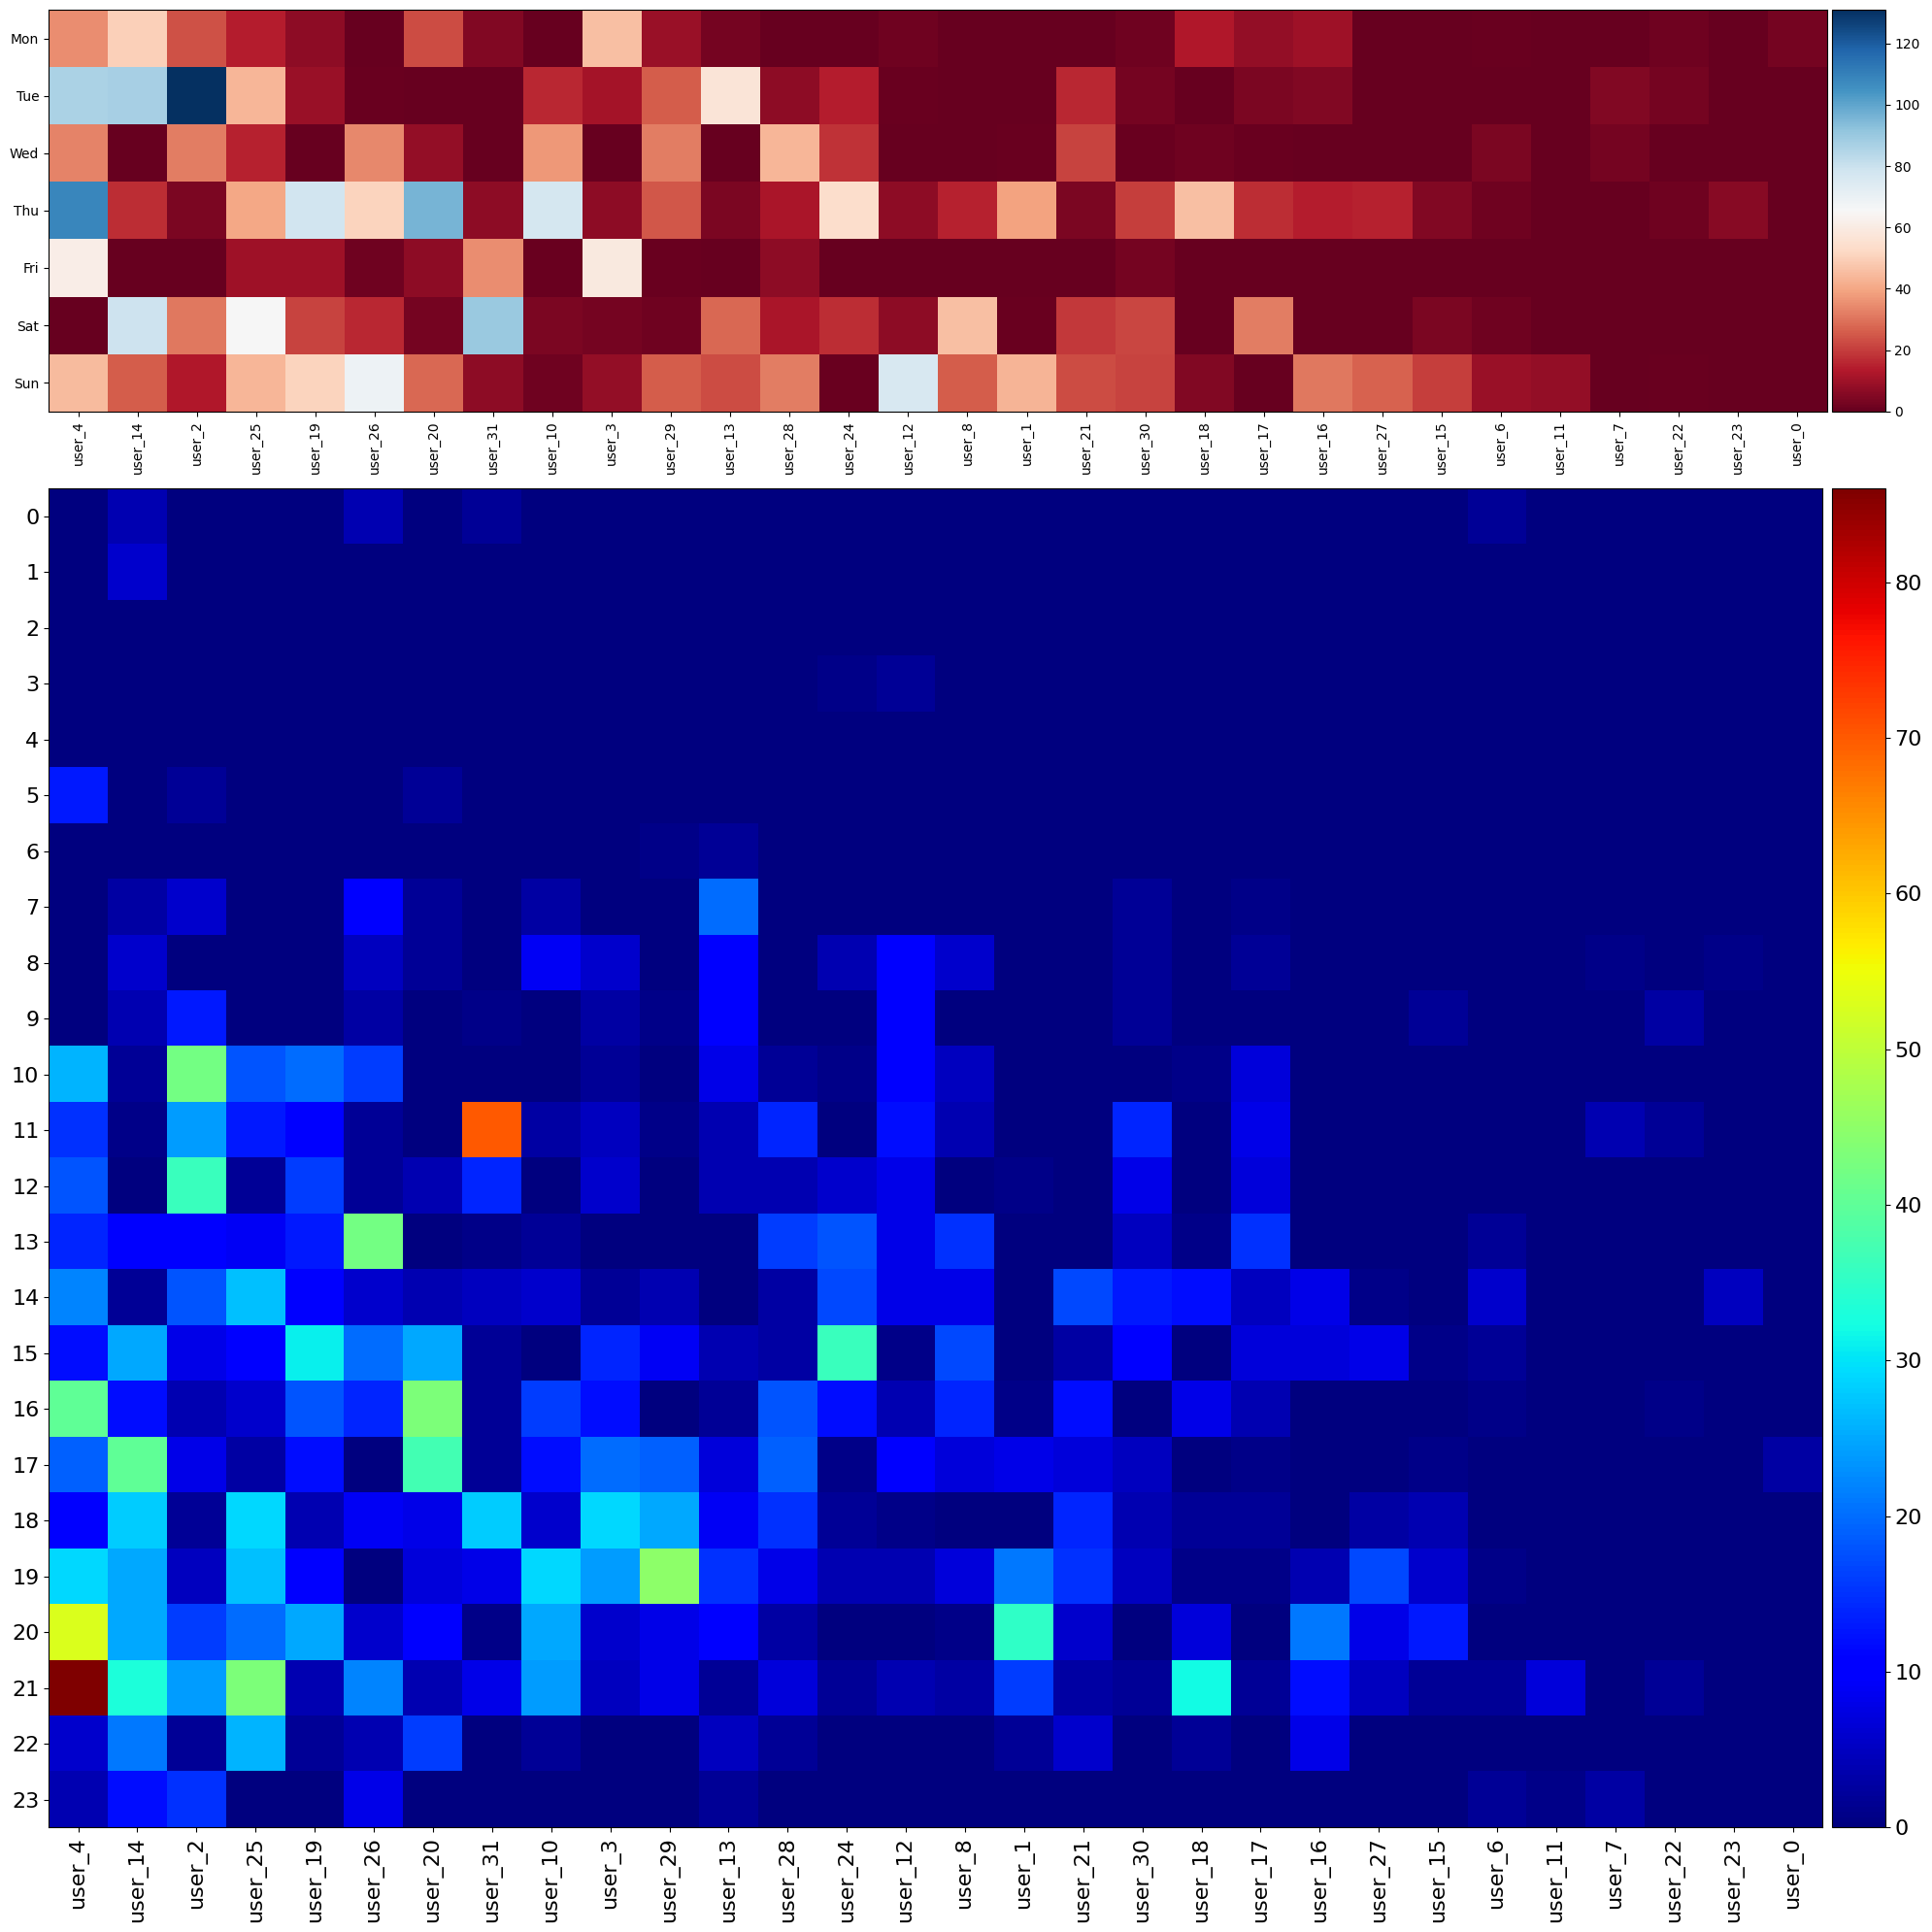

In [25]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(20, 20),
    gridspec_kw={"height_ratios": [3, 10]})

ax1 = axes[0]
im1 = ax1.imshow(day.values, aspect="auto", cmap="RdBu")
ax1.set_yticks(range(len(day.index)))
ax1.set_yticklabels(day.index)
ax1.set_xticks(range(len(day.columns)))
ax1.set_xticklabels(day.columns, rotation=90)
div1 = make_axes_locatable(ax1)
cax1 = div1.append_axes("right", size="3%", pad=0.05)
fig.colorbar(im1, cax=cax1)

ax2 = axes[1]
im2 = ax2.imshow(hour.values, aspect="auto", cmap="jet")
ax2.set_yticks(range(len(hour.index)))
ax2.set_yticklabels(hour.index)
ax2.set_xticks(range(len(hour.columns)))
ax2.set_xticklabels(hour.columns, rotation=90)
div2 = make_axes_locatable(ax2)
cax2 = div2.append_axes("right", size="3%", pad=0.1)
cax2.tick_params(labelsize=16)   
fig.colorbar(im2, cax=cax2)
ax2.tick_params(axis='x', which='major', labelsize=16)
ax2.tick_params(axis='y', which='major', labelsize=16)

plt.tight_layout()
plt.show()

## 5 У какого пользователя больше всего коммитов во вторник?
## У какого пользователя больше всего коммитов в четверг?
## В какой день недели пользователи не любят делать много коммитов?
## Какой пользователь сделал наибольшее количество коммитов в какой час?

In [26]:
tuesday_max_committer = day.loc['Tue'].idxmax()
print('Ответ: ', tuesday_max_committer)

thursday_max_committer = day.loc['Thu'].idxmax()
print('Ответ: ', thursday_max_committer)

least_active_day = day.sum(axis=1).idxmin()
print('Ответ: ', least_active_day)

most_active_user_and_hour = hour.stack().nlargest(1).reset_index()[['uid', 'hour']]
answer = f"{most_active_user_and_hour.values[0][0]}, {most_active_user_and_hour.values[0][1]}"
print('Ответ: ', answer)

Ответ:  user_2
Ответ:  user_4
Ответ:  Fri
Ответ:  user_4, 21


## 6 Закроем соединение с базой данных.

In [27]:
conn.close()